# Deriving QA thresholds

The procedure, run top to bottom: measure the [validation visits](validation-visits.md)
with the current code, derive `WARN`/`FAIL` thresholds from the known-good visits, check
them against the known-bad ones, and review them for adoption. Run it whenever the metrics
code, the visit set or the instrument changes. The rules behind it are in
[`qa-principles.md`](qa-principles.md).

Sections 3 and 4 run `pipetask`. Section 4 is the only one that writes to the Butler (one
new collection), and only when `RUN_PIPELINE` is set. Everything else reads.

**Start Jupyter from a shell with the stack set up**, so that `pipetask` and the Butler are
available to the kernel:

```bash
source /path/to/stack/loadLSST.bash
setup -r /path/to/drp_stella
setup -r /path/to/drp_qa
cd /path/to/drp_qa/docs
jupyter lab qa-thresholds.ipynb
```

Set the inputs in section 1, then run all cells. When it has run, commit it with its
outputs (section 9): they are the record of what the
thresholds were derived from.

Confirm the setup; the output is the record of what was run:

In [1]:
!eups list --setup drp_stella

   w.2026.40  	setup


In [2]:
!eups list --setup drp_qa

   LOCAL:/work/wtg/drp_qa 	setup


## 1. Inputs

The only cell to edit. Each run writes a numbered collection, `u/$USER/qa-thresholds/001`,
`002`, ..., never one that mixes code versions such as `qaActor/reductions`.
`RUN_PIPELINE = True` makes the next numbered run; `False` reads the latest one again. To
read an older run, set `RUN_NAME` to its collection.

In [3]:
import os

# Likely to change
RUN_PIPELINE = False  # True: run imageQualityQa into a new numbered collection (section 4)
RUN_NAME = None  # optional: an older run to read, e.g. "u/someone/qa-thresholds/002"

# Rarely change
PREFIX = f"u/{os.environ['USER']}/qa-thresholds"
BUTLER = "/work/datastore"
INPUTS = "PFS/defaults"  # raw data and calibrations; the notebook reduces everything itself
FILES = "~/.cache/drp_qa"  # pipetask logs and the metrics cache
# "sequence": cosmicray combines each sequence's exposures, as drpActor does, so the
# thresholds describe the reductions qaActor gates. "separate": each exposure alone, to
# measure how much grouping moves the metrics (PIPE2D-1609).
COSMIC_RAY_GROUPING = "sequence"  # or 'separate'

## Set up

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pfs.drp.qa.metrics.calibration import (
    DEFAULT_METRICS,
    METRIC_SPECS,
    calibrate,
    labelRows,
    summarizeGood,
    writeThresholds,
)
from pfs.drp.qa.metrics.readers import chooseRun, readMetrics
from pfs.drp.qa.metrics.validationVisits import (
    loadValidationVisits,
    sequenceGroups,
    sequenceTypeMismatches,
    unmatchedEntries,
    visitExpression,
)
from pfs.drp.qa.plotting import plotThresholds

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

existing = !butler query-collections {BUTLER} "{PREFIX}/*"
COLLECTION = chooseRun(existing, PREFIX, newRun=RUN_PIPELINE, runName=RUN_NAME)
PIPELINE = "../pipelines/qaThresholds.yaml"
FILES = Path(FILES).expanduser()
FILES.mkdir(parents=True, exist_ok=True)
STEM = COLLECTION.replace("/", "_")
CACHE = FILES / f"iqQaMetrics-{STEM}.parquet"
METRICS = [*DEFAULT_METRICS, "nLines"]
print(f"collection: {COLLECTION}")
print(f"files:      {FILES}")

collection: u/wtg/qa-thresholds/003
files:      /home/wtg/.cache/drp_qa


## 2. The visits

From the YAML, never typed by hand, in two passes. `drpActor` sets the reduction config by
sequence type (`ics_drpActor`, `engine.newVisitGroup`), and the thresholds must describe the
data as live QA sees it, so each pass uses that sequence type's config.

In [5]:
visitSet = loadValidationVisits()
print(
    f"{len(visitSet.knownGood)} known_good entries ({len(visitSet.goodVisits)} visits), "
    f"{len(visitSet.confirmedBad)} known_bad, {len(visitSet.unconfirmedBad)} unconfirmed; "
    f"{len(visitSet.visits)} visits"
)

# drpActor's per-sequence-type config overrides.
PASSES = {
    "arcs and traces": (
        visitSet.visitsOfType("scienceArc", "scienceTrace"),
        {
            "reduceExposure:requireAdjustDetectorMap": False,
            "isr:h4.quickCDS": True,
            "cosmicray:doNormalizeChiRms": True,
        },
    ),
    "sky": (
        visitSet.visitsOfType("scienceObject"),
        {
            "reduceExposure:requireAdjustDetectorMap": True,
            "isr:h4.quickCDS": False,
            "cosmicray:doNormalizeChiRms": True,
        },
    ),
}


def passArgs(name, visits, config):
    """Return the config options and the -d expression of one pass.

    cosmicray combines repeated exposures. drpActor reduces one sequence at a time, so
    by default each sequence is one group; with COSMIC_RAY_GROUPING = "separate" each
    exposure is its own. Written to a config file.
    """
    groups = FILES / f"cosmicray-{STEM}-{name.replace(' ', '_')}.py"
    if COSMIC_RAY_GROUPING == "sequence":
        groups.write_text(
            f'config.grouping = "manual"\nconfig.groups = {sequenceGroups(visitSet, visits)!r}\n'
        )
    elif COSMIC_RAY_GROUPING == "separate":
        groups.write_text('config.grouping = "separate"\n')
    else:
        raise ValueError(f"COSMIC_RAY_GROUPING={COSMIC_RAY_GROUPING!r}: use 'sequence' or 'separate'")
    options = " ".join(f"-c {key}={value}" for key, value in config.items())
    return f"{options} -C cosmicray:{groups}", f"instrument = 'PFS' AND {visitExpression(visits)}"


for name, (visits, config) in PASSES.items():
    options, where = passArgs(name, visits, config)
    print(f"{name}: {len(visits)} visits; {options}")
    print(f"    {where}")

28 known_good entries (72 visits), 42 known_bad, 2 unconfirmed; 123 visits
arcs and traces: 107 visits; -c reduceExposure:requireAdjustDetectorMap=False -c isr:h4.quickCDS=True -c cosmicray:doNormalizeChiRms=True -C cosmicray:/home/wtg/.cache/drp_qa/cosmicray-u_wtg_qa-thresholds_003-arcs_and_traces.py
    instrument = 'PFS' AND visit IN (133025..133055, 133532..133533, 133536..133537, 134338..134339, 135828..135850, 139971, 140005..140006, 140032, 140035, 140124..140148, 140477, 140640, 140649, 140651, 149217, 149398, 149881, 149883, 150115..150116, 150367, 150413, 150641..150642, 150661, 150779, 150782)
sky: 16 visits; -c reduceExposure:requireAdjustDetectorMap=True -c isr:h4.quickCDS=False -c cosmicray:doNormalizeChiRms=True -C cosmicray:/home/wtg/.cache/drp_qa/cosmicray-u_wtg_qa-thresholds_003-sky.py
    instrument = 'PFS' AND visit IN (134334..134337, 134880..134886, 135275..135279)


## 3. Check the inputs exist

Build each pass's graph without running it. The pipeline reduces from raw data (isr,
cosmicray, reduceExposure) and then runs `imageQualityQa`: isr, reduceExposure and
`imageQualityQa` once per detector, and cosmicray once per camera and sequence, since it
combines a sequence's repeated exposures. For the current set that is about 4,700 quanta
over about 1,400 detectors. Far fewer means raw data or
calibrations are missing from `INPUTS`. Section 5 lists any visit that ends up with no
metrics.

In [6]:
for name, (visits, config) in PASSES.items():
    options, where = passArgs(name, visits, config)
    log = FILES / f"qgraph-{STEM}-{name.replace(' ', '_')}.log"
    print(f"{name}:")
    !pipetask qgraph -b {BUTLER} -p {PIPELINE} -i {INPUTS} -o {COLLECTION} {options} -d "{where}" > {log} 2>&1
    !grep -iE "quanta|error" {log} | tail -n 5

arcs and traces:
lsst.pipe.base.quantum_graph_builder INFO: Generated 558 quanta for task cosmicray (580 removed by adjust_all_quanta).
lsst.pipe.base.quantum_graph_builder INFO: Generated 1138 quanta for task reduceExposure.
lsst.pipe.base.quantum_graph_builder INFO: Generated 1138 quanta for task imageQualityQa.
lsst.ctrl.mpexec.cli.utils INFO: QuantumGraph contains 3972 quanta for 4 tasks
Quanta     Tasks     
sky:
lsst.pipe.base.quantum_graph_builder INFO: Generated 48 quanta for task cosmicray (144 removed by adjust_all_quanta).
lsst.pipe.base.quantum_graph_builder INFO: Generated 192 quanta for task reduceExposure.
lsst.pipe.base.quantum_graph_builder INFO: Generated 192 quanta for task imageQualityQa.
lsst.ctrl.mpexec.cli.utils INFO: QuantumGraph contains 624 quanta for 4 tasks
Quanta     Tasks     


## 4. Reduce and measure

Only with `RUN_PIPELINE = True` (section 1), into the next numbered collection, which the
set-up cell chose (it refuses `RUN_PIPELINE` with `RUN_NAME`, which would write into an
older run). Each pass adds a run to that collection. Running all cells again with
`RUN_PIPELINE` still set makes another numbered run: set it back to `False` to re-read this
one. The full logs go to files; the next cell reports their outcome.

In [7]:
if RUN_PIPELINE:
    for name, (visits, config) in PASSES.items():
        options, where = passArgs(name, visits, config)
        log = FILES / f"pipetask-{STEM}-{name.replace(' ', '_')}.log"
        print(f"{name}:")
        !pipetask --long-log --log-level PFS=INFO run -j 15 -b {BUTLER} -p {PIPELINE} -i {INPUTS} -o {COLLECTION} {options} -d "{where}" > {log} 2>&1
        !tail -n 3 {log}
else:
    print(f"RUN_PIPELINE is False: using the existing {COLLECTION}")

RUN_PIPELINE is False: using the existing u/wtg/qa-thresholds/003


The outcome of each pass, read from its log file so that it is recorded here even when
the run finished with the notebook closed: the executed and failed quanta.

In [8]:
for name in PASSES:
    log = FILES / f"pipetask-{STEM}-{name.replace(' ', '_')}.log"
    print(f"{name}: {log}")
    if not log.exists():
        print("    no log: this run was made elsewhere, or not yet")
        continue
    for line in log.read_text().splitlines():
        if ("Executed" in line and " 0 remain" in line) or " - FAILED" in line:
            print("    " + line.split(" - ", 1)[-1].strip())

arcs and traces: /home/wtg/.cache/drp_qa/pipetask-u_wtg_qa-thresholds_003-arcs_and_traces.log
    Executed 3956 quanta successfully, 16 failed and 0 remain out of total 3972 quanta.
    - FAILED: <reduceExposure dataId={instrument: 'PFS', arm: 'n', spectrograph: 4, visit: 150782, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 2, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 3, visit: 150782, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 'n', spectrograph: 1, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED: <reduceExposure dataId={instrument: 'PFS', arm: 'n', spectrograph: 2, visit: 150779, dither: 42, pfs_design_id: 2004972881948851356}>
    - FAILED_DEP: <imageQualityQa dataId={instrument: 'PFS', arm: 

## 5. Read the metrics

Read-only, once; later runs read the cache. Delete the cache file to re-read.

In [9]:
if CACHE.exists():
    metrics = pd.read_parquet(CACHE)
else:
    from lsst.daf.butler import Butler

    butler = Butler(BUTLER, collections=[COLLECTION], writeable=False)
    metrics = readMetrics(butler, visitSet.visits, collections=[COLLECTION])
    metrics.to_parquet(CACHE)
print(f"{len(metrics)} rows over {metrics['visit'].nunique()} visits")
missing = sorted(set(visitSet.visits) - set(metrics["visit"]))
print(f"{len(missing)} validation visits have no metrics: {missing}")

# obsType comes from the W_SEQTYP header: a disagreement means a wrong
# sequenceType in the YAML, and a visit reduced with the wrong config.
mismatched = sequenceTypeMismatches(metrics, visitSet)
for (visit, obsType, sequenceType), _ in mismatched.groupby(["visit", "obsType", "sequenceType"]):
    print(f"visit {visit}: obsType {obsType!r} but sequenceType {sequenceType!r} in the YAML")

# An entry that matches no row is a check that silently does not run: its
# visits were not processed, or a selector (often seqType) is wrong.
for entry in unmatchedEntries(metrics, visitSet):
    print(
        f"matches no rows: visits {entry.visits[0]}-{entry.visits[-1]} "
        f"seqType={entry.seqType!r} expect={entry.expect}"
    )

1430 rows over 132 visits
0 validation visits have no metrics: []


## 6. Suggested thresholds

Derived from the known-good visits of the reference run (Run25) only. One row per metric
and population: arm and observation type; flag rates also per lamp; line counts per lamp.

In [10]:
table = calibrate(metrics, visitSet, METRICS)
columns = [
    "metric",
    "group",
    "nGood",
    "nGoodVisits",
    "median",
    "robustRms",
    "warn",
    "fail",
    "failLow",
    "failHigh",
    "goodFlaggedWarn",
    "goodFlaggedFail",
    "reliable",
    "failBounded",
    "degenerate",
    "nBad",
    "badOk",
    "nUnconfirmed",
    "unconfirmedFlagged",
]
table[columns].round(4)

,metric,group,nGood,nGoodVisits,median,robustRms,warn,fail,failLow,failHigh,goodFlaggedWarn,goodFlaggedFail,reliable,failBounded,degenerate,nBad,badOk,nUnconfirmed,unconfirmedFlagged
0,medFwhm,b/arc,184,46,2.809800e+00,0.0513,2.872,2.89,2.8851,inf,0.0489,0.0054,True,False,False,17,False,4,0.0
1,medFwhm,b/science,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,<NA>,0,NaN
2,medFwhm,b/trace,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,<NA>,4,NaN
3,medFwhm,m/arc,80,20,2.926500e+00,0.1079,3.180,3.21,3.1836,inf,0.0500,0.0125,True,False,False,0,<NA>,0,0.0
4,medFwhm,m/trace,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,<NA>,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,nLines,r/Arc: Neon,20,5,8.613920e+05,78983.7458,764000.000,762000.00,-inf,764660.0,0.0500,0.0000,True,False,False,12,True,4,0.0
62,nLines,r/Arc: Xenon,20,5,1.014906e+06,176583.2640,830000.000,800000.00,-inf,831763.0,0.0500,0.0000,True,False,False,0,<NA>,0,0.0
63,nLines,r/ImageQuality,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,<NA>,0,NaN
64,nLines,r/Trace,40,10,2.435450e+06,10817.3032,2433000.000,2433000.00,-inf,2433223.0,0.0000,0.0000,True,False,True,0,<NA>,4,2.0


In [11]:
for _, row in table[table["nBad"] > 0].iterrows():
    print(f"{row['metric']}[{row['group']}]: {row['badSummary']}")

medFwhm[b/arc]: medFwhm[b/arc]: 17 known-bad values expecting FAIL: 14 >= FAIL=2.89, 15 >= WARN=2.872  <-- threshold does not give the expected FAIL
medFwhm[b/science]: no known-good rows in this population
medFwhm[b/trace]: no known-good rows in this population
medFwhm[n/arc]: medFwhm[n/arc]: 17 known-bad values expecting FAIL: 17 >= FAIL=3.1, 17 >= WARN=3.05
medFwhm[n/science]: no known-good rows in this population
medFwhm[n/trace]: no known-good rows in this population
medFwhm[r/arc]: medFwhm[r/arc]: 17 known-bad values expecting FAIL: 17 >= FAIL=2.993, 17 >= WARN=2.987
medFwhm[r/science]: no known-good rows in this population
medFwhm[r/trace]: no known-good rows in this population
pctFlagged[arc/b/Argon]: no known-good rows in this population
pctFlagged[arc/b/Krypton]: no known-good rows in this population
pctFlagged[arc/b/Neon]: no known-good rows in this population
pctFlagged[arc/b/Xenon]: no known-good rows in this population
pctFlagged[arc/n/Neon]: pctFlagged[arc/n/Neon]: 8 kno

### Reported, not derived: `medDxCenter`

An offset from `detectorMap_calib` is near zero in the run the calibrations were made from,
so percentiles of Run25 say nothing about how much drift to tolerate: its thresholds are a
tolerance, set in PIPE2D-1921. The known-good `|medDxCenter|` per population, in px:

In [12]:
summarizeGood(metrics, visitSet, ["medDxCenter"]).round(3)

,metric,group,n,median,robustRms,p99,max
0,medDxCenter,b/arc,184,0.175,0.330,0.554,0.565
1,medDxCenter,m/arc,80,0.021,0.066,0.347,0.354
2,medDxCenter,n/arc,104,0.010,0.101,0.236,0.245
3,medDxCenter,r/arc,104,0.009,0.114,0.221,0.222


Per population: the CDF of the reference run's known-good values, `WARN` (amber) and `FAIL` (red) with
the 95 % interval on the FAIL percentile shaded, and below it the known-bad values (crosses expect FAIL, triangles WARN) and the
unconfirmed ones (open circles). A known-bad marker left
of FAIL (right of it, for `nLines`) is a fault the threshold misses.

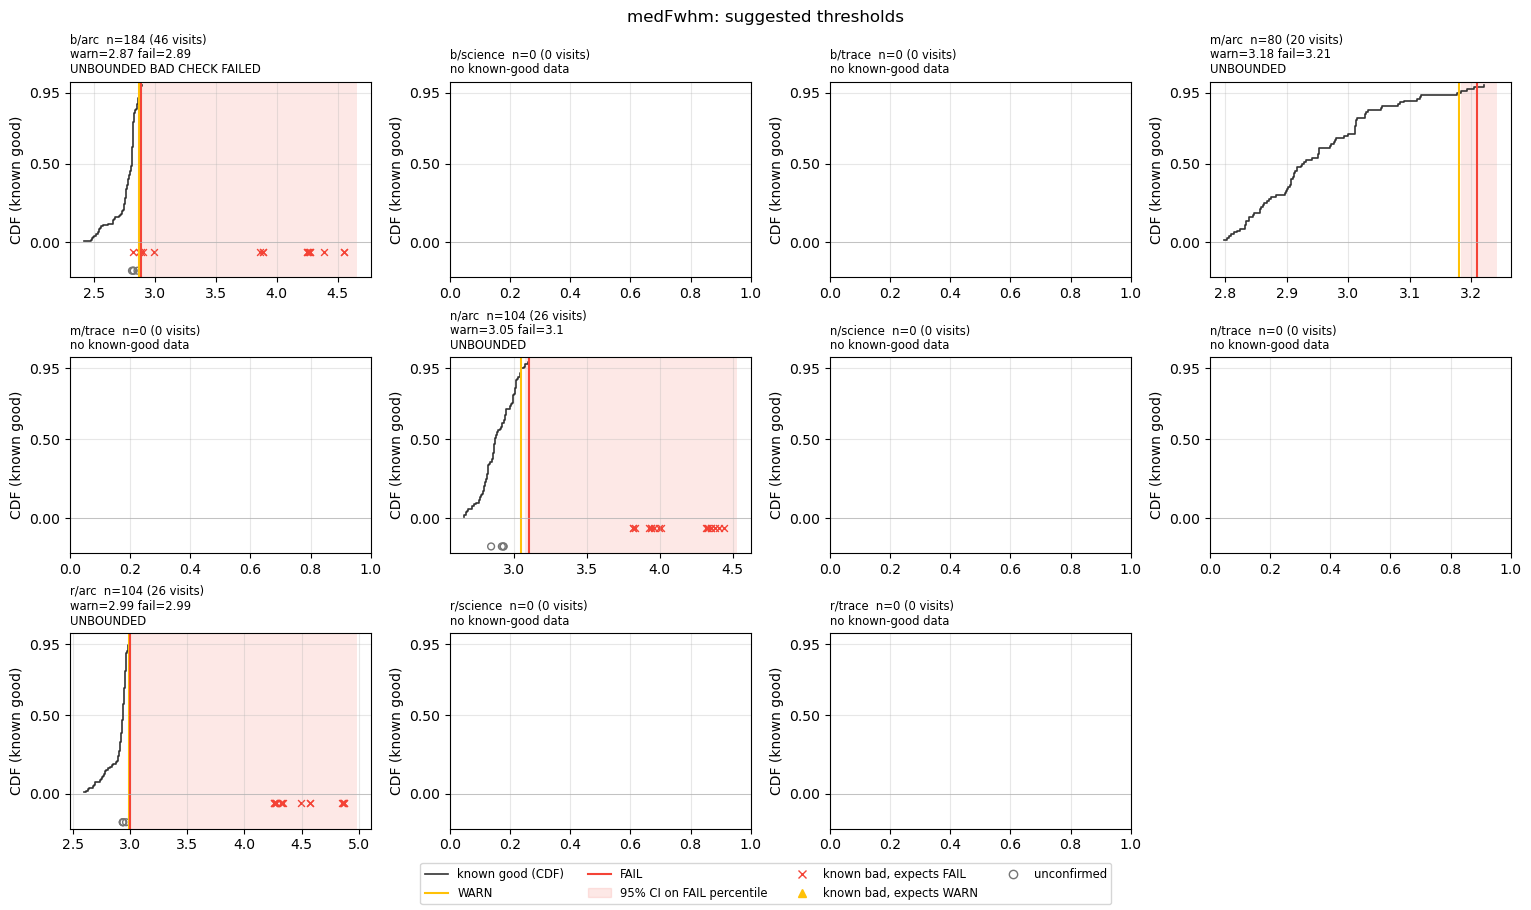

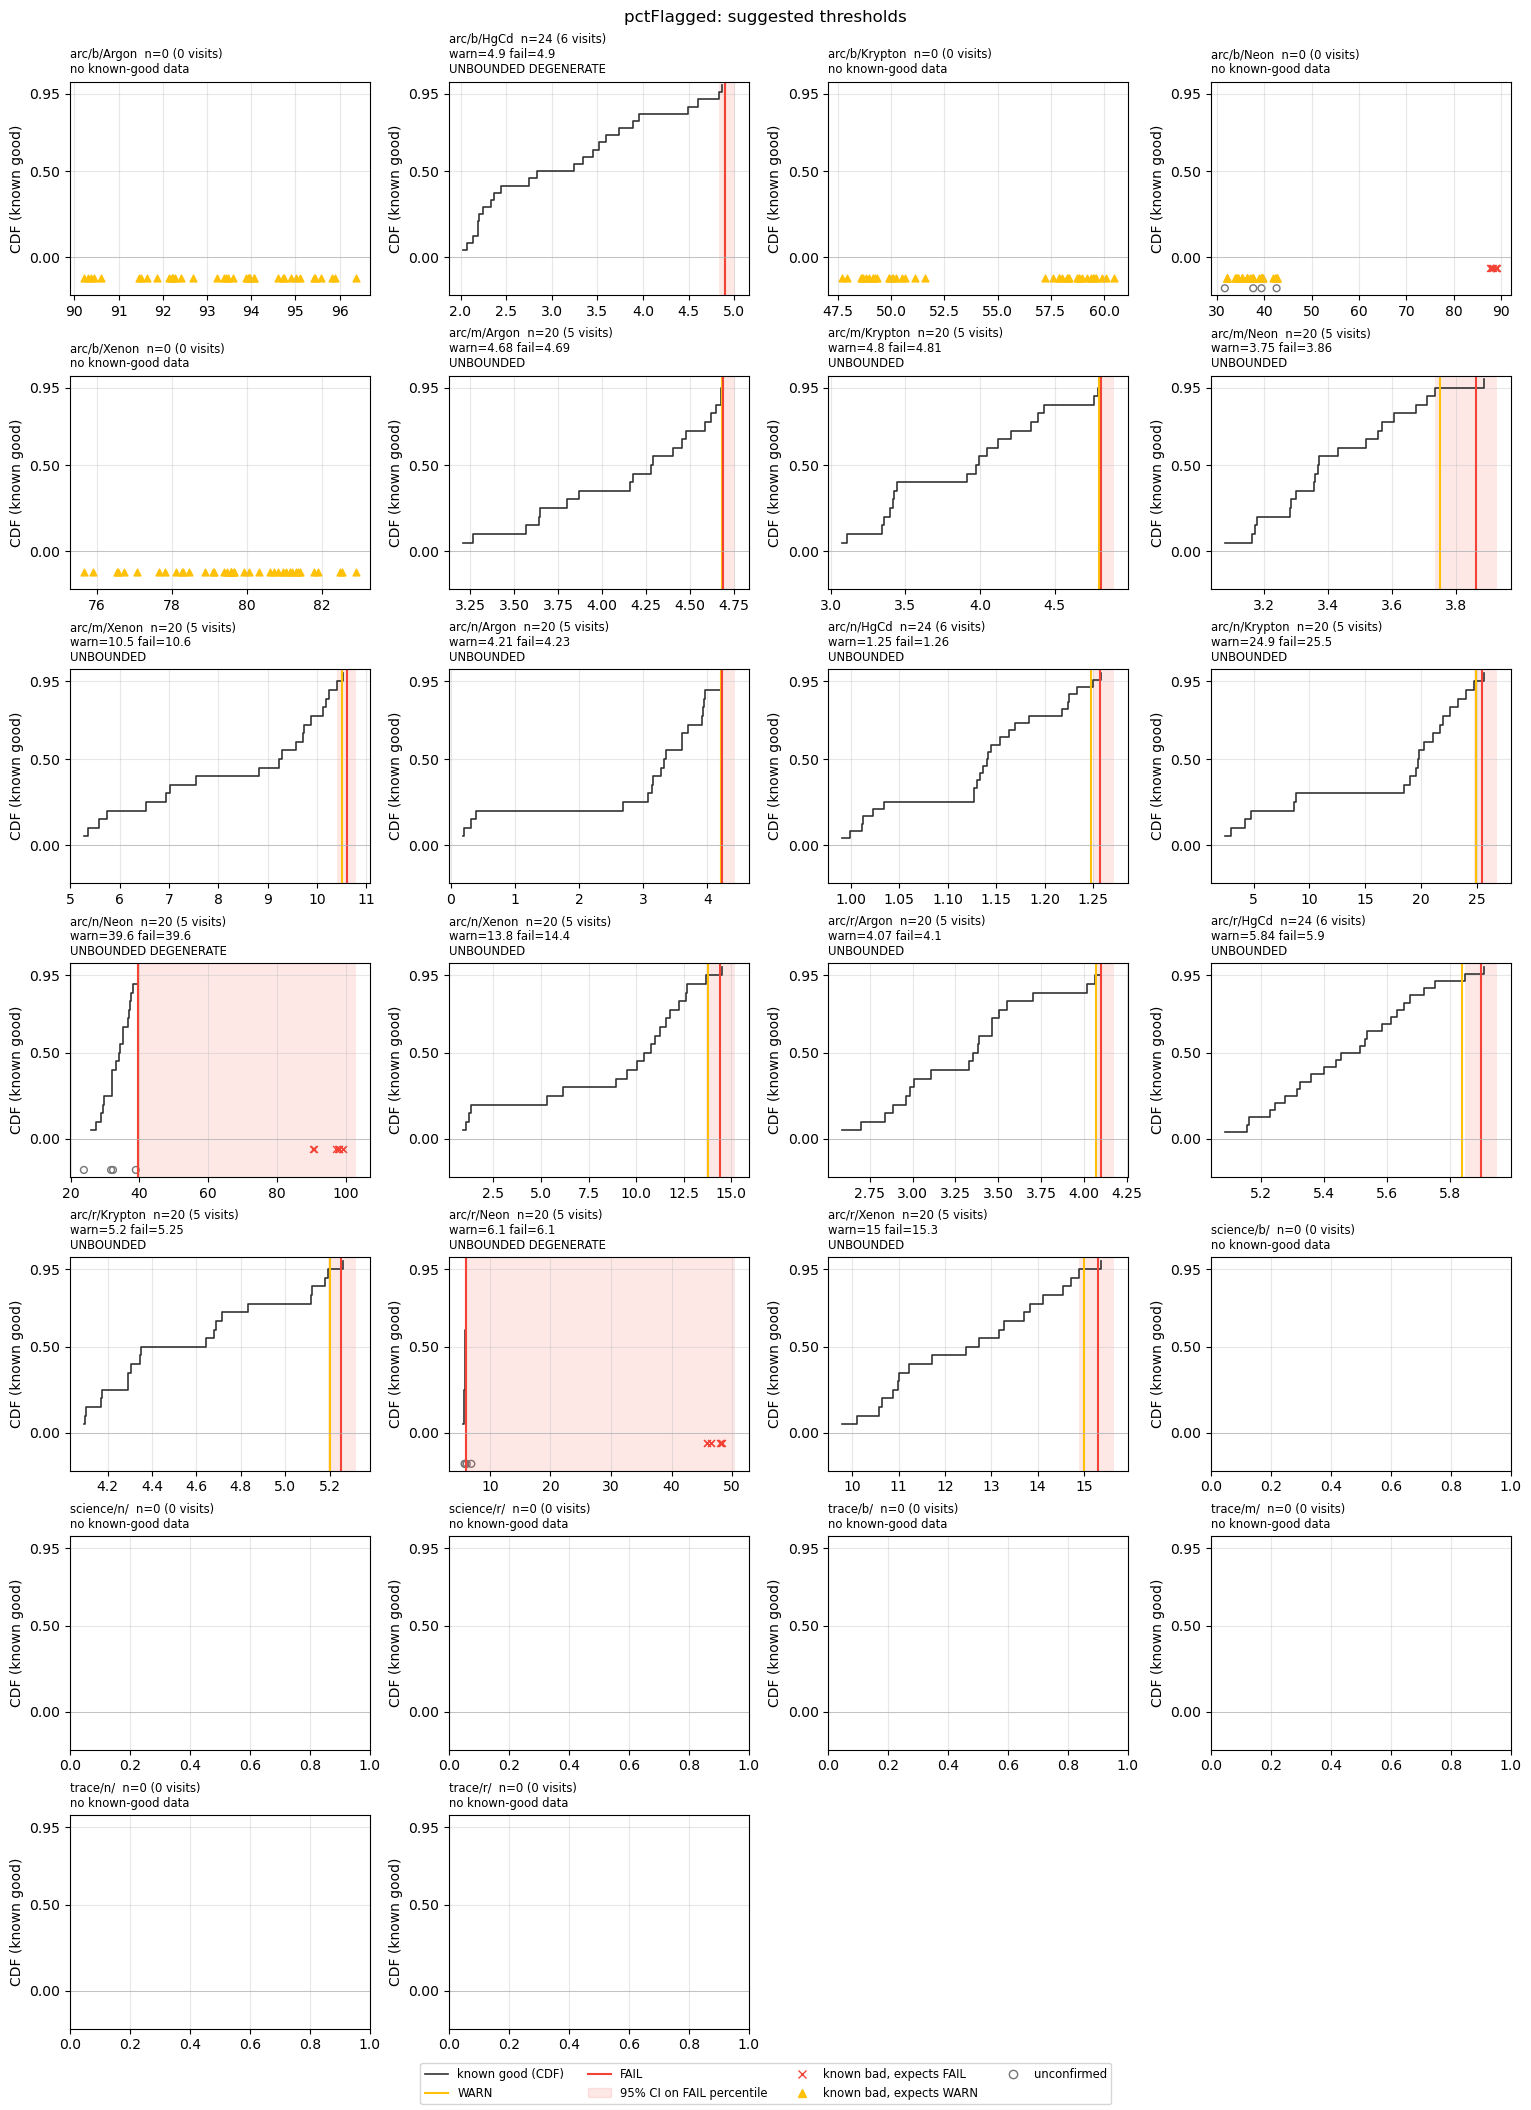

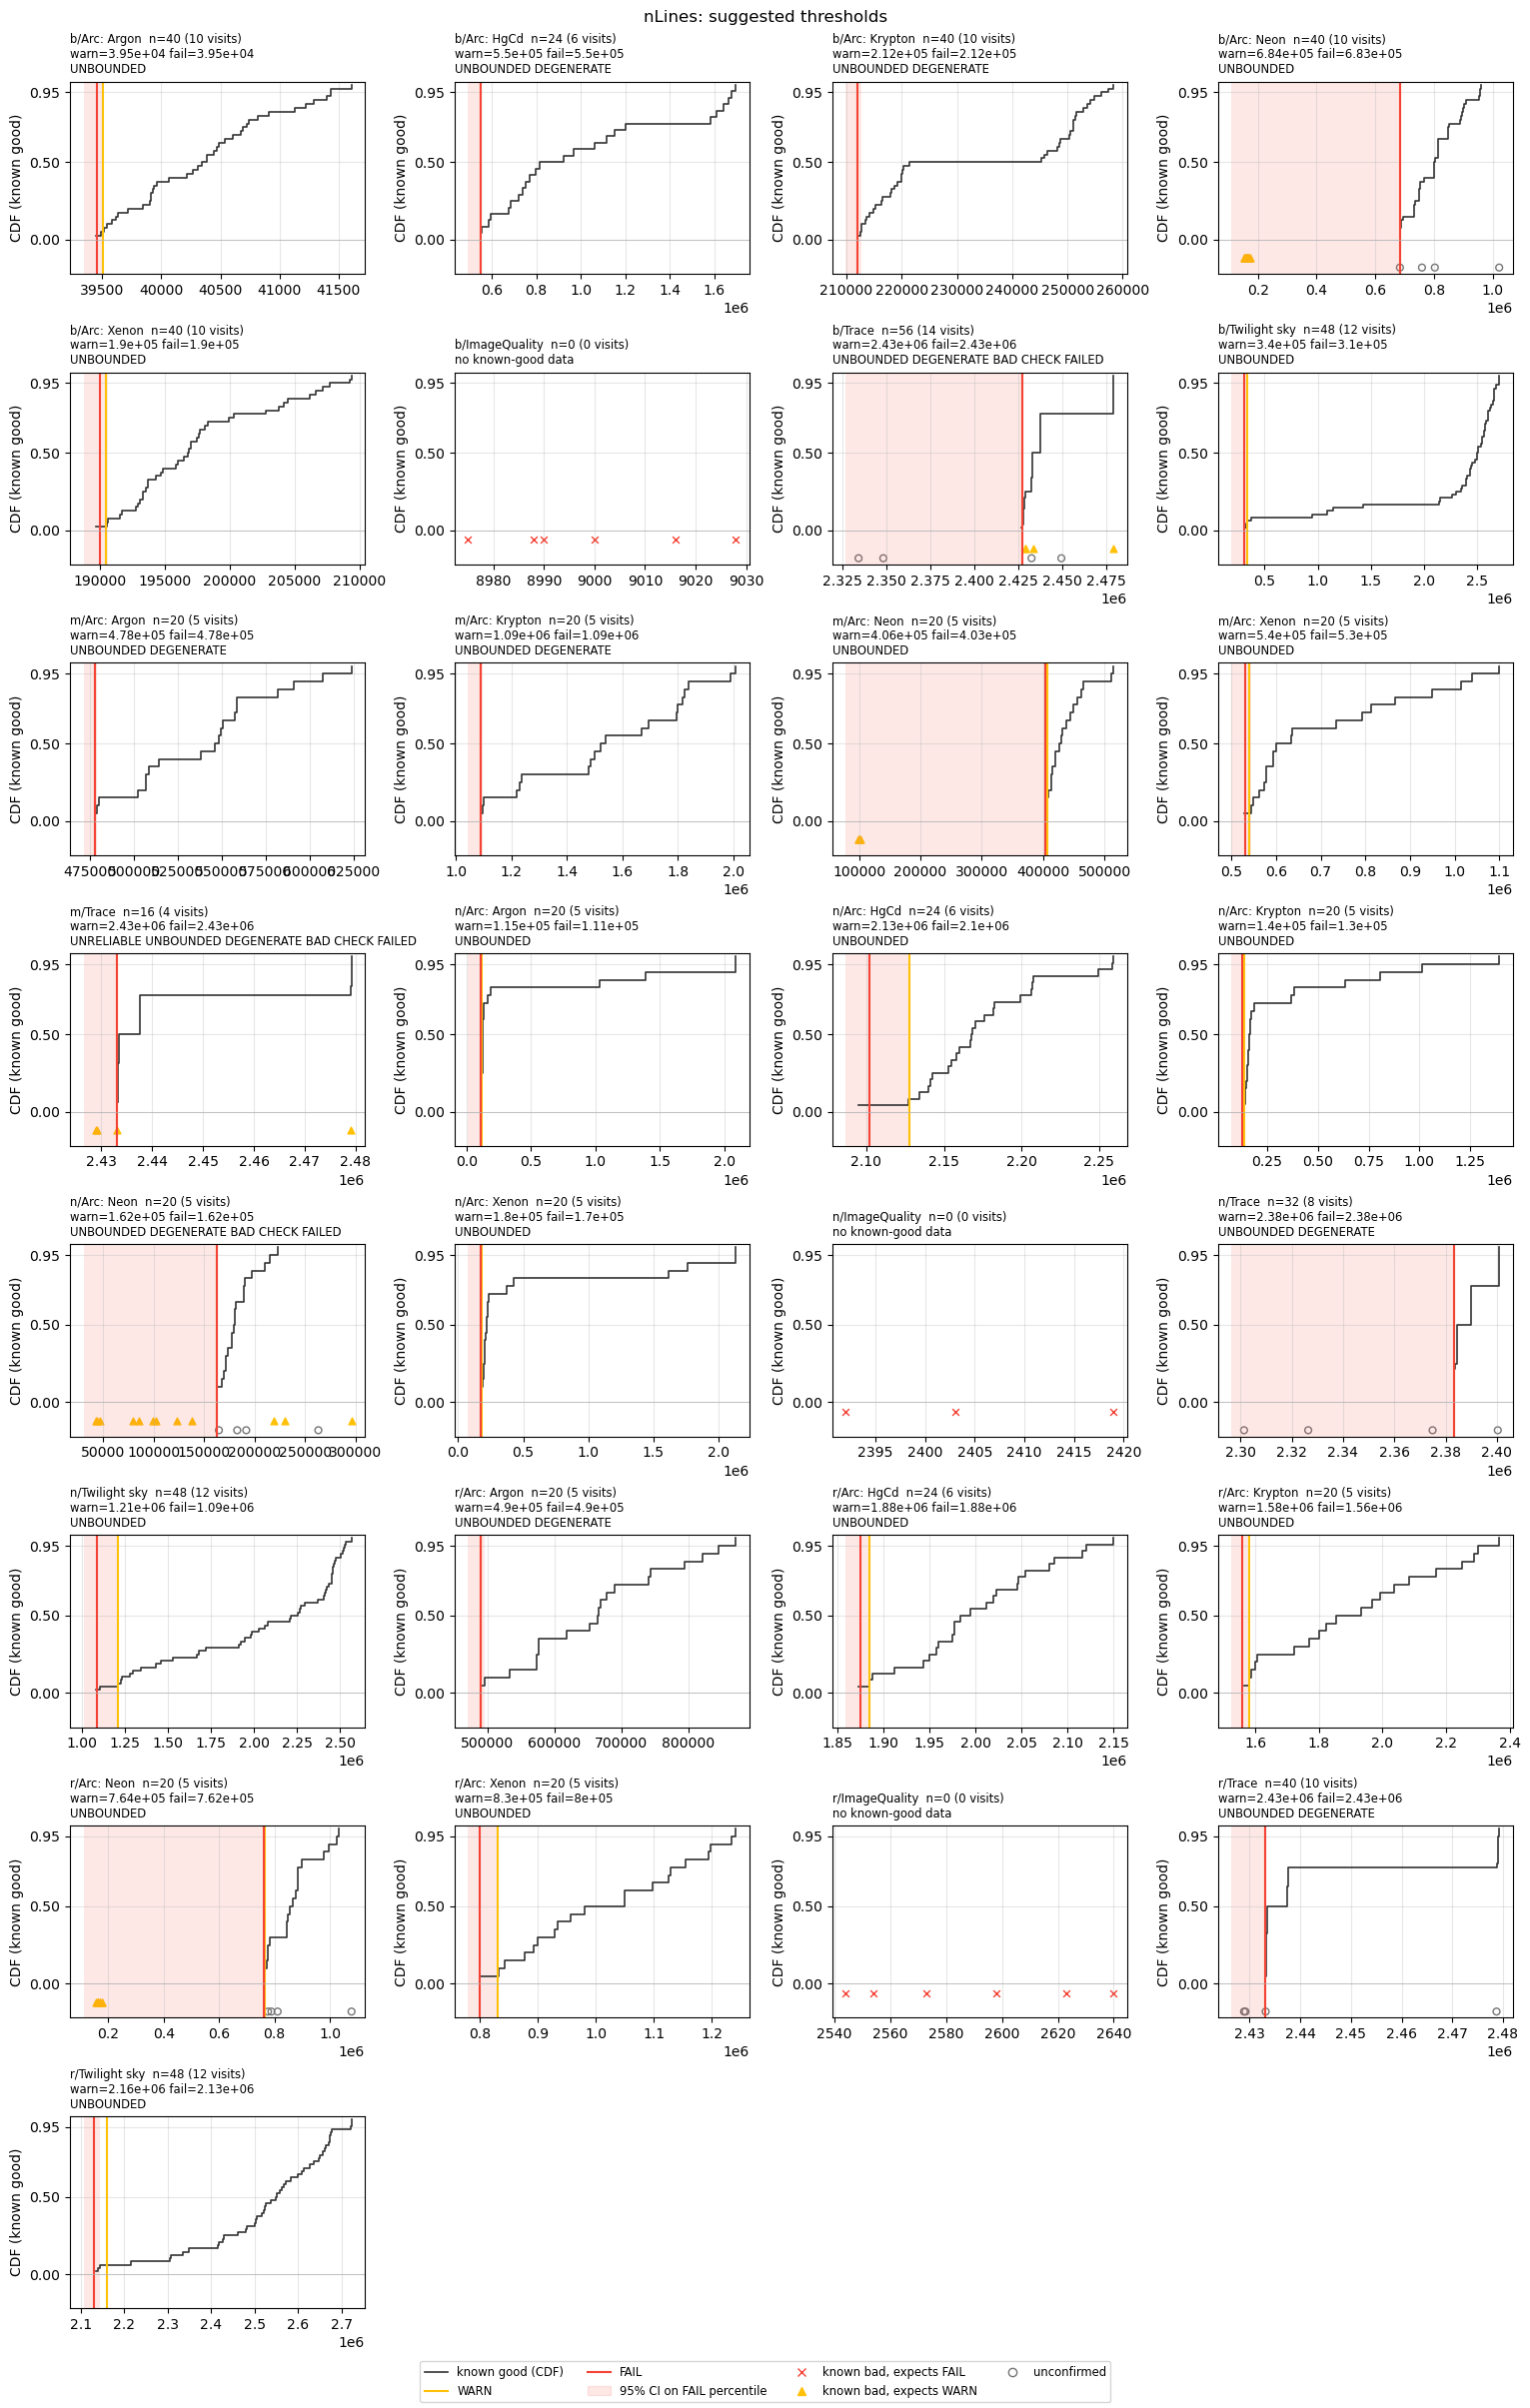

In [13]:
for metric in METRICS:
    labelled = labelRows(metrics, visitSet, metric)
    plotThresholds(labelled, table, metric, absolute=METRIC_SPECS[metric].absolute)
    plt.show()

The provenance sentences, for the `doc` of each threshold adopted:

In [14]:
for _, row in table[table["nGood"] > 0].iterrows():
    print(f"{row['metric']}[{row['group']}]: warn={row['warn']:g} fail={row['fail']:g}")
    print(f"    {row['provenance']}")

medFwhm[b/arc]: warn=2.872 fail=2.89
    Derived 2026-10-06 from validation visits 133025-135848 (n=184): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=184 cannot bound p99 at 95% confidence: its interval is open, and FAIL may move a long way with more data.
medFwhm[m/arc]: warn=3.18 fail=3.21
    Derived 2026-10-06 from validation visits 133042-135848 (n=80): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=80 cannot bound p99 at 95% confidence: its interval is open, and FAIL may move a long way with more data.
medFwhm[n/arc]: warn=3.05 fail=3.1
    Derived 2026-10-06 from validation visits 133025-135840 (n=104): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=104 cannot bound p99 at 95% confidence: its interval is open, and FAIL may move a long way with more data.
medFwhm[r/arc]: warn=2.987 fail=2.993
    Derived 2026-10-06 from validation visits 133025-135840 (n=104): WARN at p95, FAIL at p99. FAIL UNBOUNDED: n=104 cannot bound p99 at 95% confidence: its interval is open, and FAIL may move a l

The thresholds as a versioned file, for the judgement step and for review: one entry per
metric and population, with the collection, reference runs, drp_qa version and provenance.

In [15]:
import subprocess

describe = subprocess.run(
    ["git", "-C", os.environ.get("DRP_QA_DIR", ".."), "describe", "--always", "--dirty"],
    capture_output=True,
    text=True,
)
drpQaVersion = describe.stdout.strip() if describe.returncode == 0 else "unknown"
path = writeThresholds(
    table,
    FILES / f"iqQaThresholds-{STEM}.yaml",
    collection=COLLECTION,
    referenceRuns=visitSet.referenceRuns,
    drpQaVersion=drpQaVersion,
)
print(f"{path} (drp_qa {drpQaVersion})")

/home/wtg/.cache/drp_qa/iqQaThresholds-u_wtg_qa-thresholds_003.yaml (drp_qa w.2026.35-91-gbd158f3-dirty)


## 7. Review

Go through these in order:

1. **Missing visits, sequence types and unmatched entries** (section 5). A missing visit or
   an unmatched entry is a check that didn't run; a sequence-type disagreement means a
   visit was reduced with the wrong config.
   An entry whose visits are present but which matches nothing has a wrong selector:
   compare its `seqType` with the `seqName` column, character for character.
2. **Known-bad checks.** In each population with known-bad rows, `badOk` must be true. If
   not, look at the panel: a marker on the good side of `FAIL` is a missed fault. Either the
   metric doesn't see this fault, or the visit isn't bad for the reason recorded. Fix
   whichever is wrong, not the threshold.
3. **Sample size.** `reliable` is false below 20 values. `nGoodVisits` is the more honest
   count: the detectors of one visit, and back-to-back exposures, are correlated.
4. **`failBounded`.** When false, the sample is too small to bound the FAIL percentile
   (about 370 values are needed for p99): its interval is open, and `FAIL` is an estimate
   near the sample's tail. Usable,
   but expect it to move as data accumulate; the provenance sentence says so.
5. **`degenerate`.** `WARN` is not below `FAIL`, so `WARN` can never fire. It comes from
   ties in the tail; set the pair by hand from the plot.
6. **In-sample flag rates.** `goodFlaggedWarn` and `goodFlaggedFail` should be near 5 % and
   1 %. Much more means ties at the threshold.
7. **Unconfirmed visits.** `unconfirmedFlagged` counts the suspected faults the suggestion
   would flag. Use it to settle them in the YAML ([`validation-visits.md`](validation-visits.md)),
   not to move a threshold.
8. **Populations without good data.** Rows with `nGood` 0 have known-bad visits and nothing
   to compare them with. Add known-good visits for that population, or accept that it goes
   unchecked.

## 8. Adopt

`imageQualityQa` judges with a thresholds file when its `thresholdsFile` config field names
one (`pfs.drp.qa.metrics.gate`): each metric by the file's entry for its population, and by
the threshold config fields where the file has none. Adopting a file changes verdicts, so it
is done on a ticket of its own (for the first derivation, PIPE2D-1917).

1. Re-judge the stored metrics with the file, without reducing anything, and compare with
   today's verdicts:
   ```python
   from pfs.drp.qa.imageQualityQa import ImageQualityQaConfig
   from pfs.drp.qa.metrics.gate import configThresholds, gate, judge

   config = configThresholds(ImageQualityQaConfig())
   verdicts = gate(metrics, [path, config])
   ```
   `judge` gives each metric's verdict and the entry that set it; `layer` 1 marks a
   population the file has no entry for, judged by the config.
2. Every known-good visit should pass and every known-bad one reach its expected verdict.
   Note the exceptions, and the populations left to the config, on the ticket.
3. Update the threshold tables in the README (`imageQualityQa` → *Pass/Warn/Fail
   Thresholds*) and add a line under `## [Unreleased]` in `CHANGELOG.md`.

## 9. Commit

Commit this notebook with its outputs on the ticket branch. It shows only validation visits,
which are engineering and calibration visits, so its outputs are fine to publish.

```bash
git add docs/qa-thresholds.ipynb
git commit
```